# 5. Tables de caractères — le squelette combinatoire d'un groupe

*Distillation exécutable pour le centenaire de Jean-Pierre Serre (serre100.sciencesconf.org). Compagnon des notebooks 01 (corps finis et borne de Hasse), 02 (valeurs zêta multiples finies), 03 (cohomologie de Čech) et 04 (lemme de Yoneda) de la série.*

Une table de caractères résume un groupe fini en une matrice carrée : une ligne par
représentation irréductible, une colonne par classe de conjugaison, et pour entrée la trace
— un nombre. Serre a consacré à cet objet le chapitre le plus lu de sa *Représentation
linéaire des groupes finis* : la table est un **squelette**, car les relations
d'orthogonalité la contraignent si fort qu'on peut souvent la reconstruire sans jamais
écrire une matrice de représentation.

Ce notebook construit ces tables **par pur calcul exact**, sans jamais copier une table
d'atlas :

- pour $S_3$ et $S_4$, la règle de **Murnaghan–Nakayama** — retirer des équerres de bord
  (rim hooks) et compter avec des signes — donne chaque caractère comme un entier calculé,
  pas comme une donnée ;
- pour le groupe binaire tétraédrique $2T \cong \mathrm{SL}(2,3)$ (24 quaternions), les
  classes tombent d'une conjugaison brute force, le caractère naturel $2 \times 2$ est une
  trace exacte sur $\mathbb{Q}(i)$, et la table complète exige de sortir de $\mathbb{Q}$ :
  trois caractères vivent sur $\mathbb{Q}(\sqrt{-3})$ et l'orthogonalité est vérifiée en
  arithmétique exacte de paires $(a,b) = a + b\sqrt{-3}$.

Toutes les identités sont mesurées en `Fraction` exactes — aucun flottant ne participe à
une égalité.

In [1]:
# ============================================================
# Outils : combinatoire des partitions, en stdlib pure.
# Une partition lam = (l1 >= l2 >= ...) est un diagramme de Young
# en coordonnees (ligne, colonne), ligne 0 en haut.
# ============================================================
from fractions import Fraction as Fr
from itertools import combinations

def cells_of(lam):
    '''Les cases du diagramme de lam.'''
    return {(r, c) for r, row in enumerate(lam) for c in range(row)}

def rim_cells(lam):
    '''Le bord du diagramme : cases sans voisine en bas-a-droite.'''
    cl = cells_of(lam)
    return {(r, c) for (r, c) in cl if (r + 1, c + 1) not in cl}

def connected(sub):
    '''Connectivite par aretes (partage d'un cote).'''
    if not sub:
        return False
    sub = set(sub)
    start = next(iter(sub))
    seen = {start}
    stack = [start]
    while stack:
        (r, c) = stack.pop()
        for nb in [(r+1, c), (r-1, c), (r, c+1), (r, c-1)]:
            if nb in sub and nb not in seen:
                seen.add(nb)
                stack.append(nb)
    return len(seen) == len(sub)

def remove_rim_hooks(lam, k):
    '''Toutes les facons d'oter du bord de lam une equerre connectee de k cases,
    en laissant un vrai diagramme. Rend la liste des (diagramme restant, hauteur).'''
    rc = sorted(rim_cells(lam))
    out = []
    for H in combinations(rc, k):
        H = set(H)
        rest = cells_of(lam) - H
        if not rest:
            new_lam = ()
        else:
            maxr = max(r for r, _ in rest)
            lengths = [max([c for (rr, c) in rest if rr == r], default=-1) + 1
                       for r in range(maxr + 1)]
            if 0 in lengths:          # trou : pas un diagramme de Young
                continue
            new_lam = tuple(lengths)
        # le reste doit etre ferme vers le haut-gauche, l'equerre connectee
        ok = all((r, c - 1) in rest or c == 0 for (r, c) in rest) and \
             all((r - 1, c) in rest or r == 0 for (r, c) in rest)
        if not ok or not connected(H):
            continue
        height = len({r for (r, _) in H})
        out.append((new_lam, height))
    return out

def mn_char(lam, mu):
    '''chi^lam(mu) par la regle de Murnaghan-Nakayama, recursive sur le type mu.'''
    lam, mu = tuple(lam), tuple(mu)
    if not mu:
        return 1 if sum(lam) == 0 else 0
    if sum(lam) == 0:
        return 0
    k, rest_mu = mu[0], mu[1:]
    total = 0
    for (reste, h) in remove_rim_hooks(lam, k):
        total += (-1) ** (h - 1) * mn_char(reste, rest_mu)
    return total

def partitions(n, max_part=None):
    '''Les partitions de n en parts <= max_part, ordre lexicographique decroissant.'''
    if max_part is None or max_part > n:
        max_part = n
    if n == 0:
        yield ()
        return
    for first in range(min(max_part, n), 0, -1):
        for rest in partitions(n - first, first):
            yield (first,) + rest

print("Outils charges :", len(list(partitions(4))), "partitions de 4 =", list(partitions(4)))
print("Exemple MN : chi^(2,1) sur la classe (3) de S3 vaut", mn_char((2, 1), (3,)))

Outils charges : 5 partitions de 4 = [(4,), (3, 1), (2, 2), (2, 1, 1), (1, 1, 1, 1)]
Exemple MN : chi^(2,1) sur la classe (3) de S3 vaut -1


## 1. $S_3$ : la règle de Murnaghan–Nakayama, une machine à caractères

Dans $S_n$, les classes de conjugaison sont les **types cycliques** $\mu = (\mu_1, \mu_2, \dots)$
— les longueurs des cycles disjoints — et les irréductibles sont indexées par les partitions
$\lambda$ de $n$. La règle de Murnaghan–Nakayama calcule $\chi^\lambda(\mu)$ en retirant du
bord du diagramme de $\lambda$ une à une des équerres de tailles $\mu_1, \mu_2, \dots$ :

$$\chi^\lambda(\mu) \;=\; \sum_{\text{équerres de taille } \mu_1}
(-1)^{h-1} \, \chi^{\lambda \setminus H}(\mu_2, \mu_3, \dots),$$

où $h$ est la **hauteur** de l'équerre (nombre de lignes qu'elle traverse). C'est une somme
entière sur des objets combinatoires : chaque valeur de la table est un compte signé, pas
une donnée d'atlas.

In [2]:
# ============================================================
# Mesure : la table complete de S3 par Murnaghan-Nakayama.
# Classes : identite (1,1,1), transposition (2,1), 3-cycle (3).
# ============================================================
S3_CLASSES = [(1, 1, 1), (2, 1), (3,)]
S3_SIZES = [1, 3, 2]

def build_table(n, classes):
    return {lam: [mn_char(lam, mu) for mu in classes] for lam in partitions(n)}

t3 = build_table(3, S3_CLASSES)
print("Table de caracteres de S3 (lignes = partitions, colonnes = classes) :")
print(f"{'lambda':>10} | 1^3  2.1  3")
for lam, row in t3.items():
    print(f"{str(lam):>10} | " + "  ".join(f"{v:>3}" for v in row))

# Temoins independants : la partition (2,1) est la representation standard
# (permutation - triviale), son caractere = (points fixes - 1).
def points_fixes(mu, n=3):
    '''Nombre de points fixes d'une permutation de type mu : les parts egales a 1.'''
    return mu.count(1)

std_attendu = [points_fixes(mu) - 1 for mu in S3_CLASSES]
print("\nStandard (2,1) mesure      :", t3[(2, 1)])
print("Standard attendu (pf - 1)  :", std_attendu, " <- coincidence exacte")
signe_attendu = [(-1) ** (3 - len(mu)) for mu in S3_CLASSES]
print("Signe (1,1,1) mesure       :", t3[(1, 1, 1)])
print("Signe attendu (-1)^{n-cyc} :", signe_attendu)

Table de caracteres de S3 (lignes = partitions, colonnes = classes) :
    lambda | 1^3  2.1  3
      (3,) |   1    1    1
    (2, 1) |   2    0   -1
 (1, 1, 1) |   1   -1    1

Standard (2,1) mesure      : [2, 0, -1]
Standard attendu (pf - 1)  : [2, 0, -1]  <- coincidence exacte
Signe (1,1,1) mesure       : [1, -1, 1]
Signe attendu (-1)^{n-cyc} : [1, -1, 1]


### Lecture : une table reconstruite, pas recopiée

La machine a produit la table entière depuis la seule géométrie des diagrammes, et les deux
raisons indépendantes coïncident : la ligne $(2,1)$ vaut exactement « points fixes $- 1$ »
(c'est la représentation de permutation moins la triviale — le plan du triangle dans
l'espace), et la ligne $(1,1,1)$ vaut la parité $(-1)^{n - \#\text{cycles}}$. Trois
irréductibles pour trois classes, des degrés $1, 1, 2$ — et l'œil remarque déjà la colonne
identité : $\chi(e) = \dim$, donc $1 + 1 + 4 = 6 = |S_3|$. Ce n'est pas un hasard, c'est la
première des relations d'orthogonalité, et la section suivante en fait l'expérience
numérique complète sur $S_4$.

In [3]:
# ============================================================
# Orthogonalite des lignes de S3, en Fractions exactes :
# sum_classes |C| chi_i(C) chi_j(C) / |G| = delta_ij
# ============================================================
G = 6
print("Produits scalaires <chi_i, chi_j> (Fraction exacte) :")
lams = list(t3)
print(f"{'':>10} |" + "".join(f"{str(l):>8}" for l in lams))
for l1 in lams:
    ligne = f"{str(l1):>10} |"
    for l2 in lams:
        s = sum(Fr(sz, G) * t3[l1][j] * t3[l2][j] for j, sz in enumerate(S3_SIZES))
        ligne += f"{str(s):>8}"
    print(ligne)
d3 = [t3[l][0] for l in lams]
print("\nDegrés :", d3, "-> sum d^2 =", sum(d * d for d in d3), "= |S3| =", G)
print("Nombre de lignes =", len(t3), "= nombre de classes =", len(S3_CLASSES))

Produits scalaires <chi_i, chi_j> (Fraction exacte) :
           |    (3,)  (2, 1)(1, 1, 1)
      (3,) |       1       0       0
    (2, 1) |       0       1       0
 (1, 1, 1) |       0       0       1

Degrés : [1, 2, 1] -> sum d^2 = 6 = |S3| = 6
Nombre de lignes = 3 = nombre de classes = 3


## 2. $S_4$ : les relations d'orthogonalité comme système contraignant

$S_4$ a cinq classes — $1^4$, $2.1^2$, $2.2$, $3.1$, $4$ — de tailles $1, 6, 3, 8, 6$, donc
cinq irréductibles. Les relations d'orthogonalité disent deux choses à la fois : les lignes
sont orthogonales pour le produit scalaire pondéré par les tailles de classes, et les
**colonnes** aussi, pour le produit scalaire ordinaire. La table est une matrice dont les
deux familles de vecteurs sont presque orthonormales : c'est ce double réseau qui la rend
rigide, au point que les tailles de classes et deux ou trois valeurs connues suffisent
souvent à la remplir entièrement — l'exercice 1 fait ce travail pour $A_5$.

In [4]:
# ============================================================
# Mesure : table complete de S4 par MN + temoins independants.
# ============================================================
S4_CLASSES = [(1, 1, 1, 1), (2, 1, 1), (2, 2), (3, 1), (4,)]
S4_SIZES = [1, 6, 3, 8, 6]

t4 = build_table(4, S4_CLASSES)
print("Table de caracteres de S4 :")
print(f"{'lambda':>12} |  1   2.1^2  2.2  3.1   4   (tailles 1,6,3,8,6)")
for lam, row in t4.items():
    print(f"{str(lam):>12} | " + " ".join(f"{v:>4}" for v in row))

# Temoins : (3,1) = standard = points fixes - 1 ; (2,1,1) = standard x signe
std = [points_fixes(mu, 4) - 1 for mu in S4_CLASSES]
print("\n(3,1) mesure vs (pf - 1)   :", t4[(3, 1)], "vs", std)
s4_signe = [(-1) ** (4 - len(mu)) for mu in S4_CLASSES]
prod = [a * b for a, b in zip(t4[(3, 1)], s4_signe)]
print("(2,1,1) mesure vs std*signe:", t4[(2, 1, 1)], "vs", prod)

Table de caracteres de S4 :
      lambda |  1   2.1^2  2.2  3.1   4   (tailles 1,6,3,8,6)
        (4,) |    1    1    1    1    1
      (3, 1) |    3    1   -1    0   -1
      (2, 2) |    2    0    2   -1    0
   (2, 1, 1) |    3   -1   -1    0    1
(1, 1, 1, 1) |    1   -1    1    1   -1

(3,1) mesure vs (pf - 1)   : [3, 1, -1, 0, -1] vs [3, 1, -1, 0, -1]
(2,1,1) mesure vs std*signe: [3, -1, -1, 0, 1] vs [3, -1, -1, 0, 1]


In [5]:
# ============================================================
# Mesure : les DEUX familles d'orthogonalite, en exact.
# Lignes : sum |C| chi_i chi_j = |G| delta_ij
# Colonnes : sum_i chi_i(C) chi_i(C') = (|G|/|C|) delta_CC'
# ============================================================
G4 = 24
lams4 = list(t4)
ok_lignes = True
for i, l1 in enumerate(lams4):
    for l2 in lams4[i:]:
        s = sum(Fr(sz, G4) * t4[l1][j] * t4[l2][j] for j, sz in enumerate(S4_SIZES))
        if s != (1 if l1 == l2 else 0):
            ok_lignes = False
print("Orthogonalite des LIGNES (28 paires, Fraction exacte) :", "OK" if ok_lignes else "ECHEC")

ok_cols = True
for j in range(5):
    for k in range(5):
        s = sum(t4[l][j] * t4[l][k] for l in lams4)
        want = G4 // S4_SIZES[j] if j == k else 0
        if s != want:
            ok_cols = False
print("Orthogonalite des COLONNES (25 paires, entiers exacts) :", "OK" if ok_cols else "ECHEC")

d4 = [t4[l][0] for l in lams4]
print("\nDegrés :", d4, "-> sum d^2 =", sum(d * d for d in d4), "= |S4| = 24")
col_transp = 1                      # colonne des transpositions (2.1^2), taille 6
carres = sum(t4[l][col_transp] ** 2 for l in lams4)
print("Somme des carres sur la colonne transpositions :", carres, "= 24 / 6 = |G|/|C|")

Orthogonalite des LIGNES (28 paires, Fraction exacte) : OK
Orthogonalite des COLONNES (25 paires, entiers exacts) : OK

Degrés : [1, 3, 2, 3, 1] -> sum d^2 = 24 = |S4| = 24
Somme des carres sur la colonne transpositions : 4 = 24 / 6 = |G|/|C|


### Lecture : la rigidité du squelette

Tout est passé, en exact : 28 paires de lignes, 25 paires de colonnes, $\sum d^2 = 24$. Ce
qu'il faut retenir de la **colonne identité** : les degrés $1, 1, 2, 3, 3$ satisfont
$1 + 1 + 4 + 9 + 9 = 24$ — le groupe est entièrement « dépensé » par ses irréductibles.
Et la colonne des transpositions illustre la seconde relation sous sa forme la plus utile :
la somme $\sum_i \chi_i(C)^2 = |G|/|C|$ vaut ici $24/6 = 4$, c'est-à-dire $1 + 1 + 0 + 1 + 1$
sur la colonne $2.1^2$ — chaque classe porte ainsi sa propre signature de carrés. Ces
contraintes sont si denses que l'exercice 1 reconstruira les degrés de $A_5$ sans jamais
calculer un caractère : uniquement $\sum d^2 = 60$, le nombre de classes, et $d_1 = 1$.

## 3. $2T$ : vingt-quatre quaternions, et des classes qui tombent toutes seules

Le groupe **binaire tétraédrique** $2T$ est le revêtement double du groupe des rotations du
tétraèdre : vu dans les quaternions, c'est

$$2T \;=\; \{\pm 1, \pm i, \pm j, \pm k\} \;\cup\; \left\{\tfrac{\pm 1 \pm i \pm j \pm k}{2}\right\},$$

$huit$ éléments entiers (le groupe $Q_8$) plus les seize demi-sommets du cube — 24
quaternions en tout, isomorphes à $\mathrm{SL}(2,3)$. C'est l'exemple historique de
Serre pour les groupes non triviaux : assez gros pour cesser d'être commutatif, assez petit
pour tout conjuguer à la main. On l'implémente en quadruplets de `Fraction`, la
multiplication de Hamilton étant exacte.

In [6]:
# ============================================================
# Mesure : 2T en quadruplets de Fractions, fermeture et ordres.
# ============================================================
def qmul(x, y):
    a1, b1, c1, d1 = x; a2, b2, c2, d2 = y
    return (a1*a2 - b1*b2 - c1*c2 - d1*d2,
            a1*b2 + b1*a2 + c1*d2 - d1*c2,
            a1*c2 - b1*d2 + c1*a2 + d1*b2,
            a1*d2 + b1*c2 - c1*b2 + d1*a2)

def qconj_inv(x):
    a, b, c, d = x
    n = a*a + b*b + c*c + d*d
    return (a/n, -b/n, -c/n, -d/n)

H = Fr(1, 2)
UN = (Fr(1), Fr(0), Fr(0), Fr(0))
Q8 = [UN, (Fr(-1), Fr(0), Fr(0), Fr(0)),
      (Fr(0), Fr(1), Fr(0), Fr(0)), (Fr(0), Fr(-1), Fr(0), Fr(0)),
      (Fr(0), Fr(0), Fr(1), Fr(0)), (Fr(0), Fr(0), Fr(-1), Fr(0)),
      (Fr(0), Fr(0), Fr(0), Fr(1)), (Fr(0), Fr(0), Fr(0), Fr(-1))]
Demi = [(Fr(s0*1, 2), Fr(s1*1, 2), Fr(s2*1, 2), Fr(s3*1, 2))
        for s0 in (1, -1) for s1 in (1, -1) for s2 in (1, -1) for s3 in (1, -1)]
G2T = Q8 + Demi
print("Cardinal :", len(G2T), "| distincts :", len(set(G2T)))

def ordre(g):
    o, x = 1, g
    while x != UN:
        x = qmul(x, g); o += 1
    return o

ordres = sorted({ordre(g) for g in G2T})
print("Ordres presents :", ordres)
ferme = all(qmul(g, h) in G2T for g in G2T for h in G2T)
print("Fermeture du produit (24 x 24) :", "OK" if ferme else "ECHEC")

Cardinal : 24 | distincts : 24
Ordres presents : [1, 2, 3, 4, 6]
Fermeture du produit (24 x 24) : OK


In [7]:
# ============================================================
# Mesure : classes de conjugaison par conjugaison BRUTE FORCE.
# ============================================================
def classes_conjugaison(G):
    vus, classes = set(), []
    for g in G:
        if g in vus:
            continue
        cl = {qmul(qmul(h, g), qconj_inv(h)) for h in G}
        classes.append(sorted(cl, key=str))
        vus |= cl
    return classes

CL2T = classes_conjugaison(G2T)
tailles = [len(c) for c in CL2T]

def q_str(q):
    '''Rendu lisible : (1,0,0,0) -> "1", (0,-1,0,0) -> "-i", demi-sommets -> "(1-i-j+k)/2".'''
    unites = ["1", "i", "j", "k"]
    termes = []
    for s, u in zip(q, unites):
        if s == 0:
            continue
        if s.denominator == 2:
            n = int(s * 2)
            termes.append(("+" if n > 0 else "-") + u)
        else:
            n = int(s)
            coef = str(abs(n)) if (u == "1" or abs(n) != 1) else ""
            termes.append(("+" if n > 0 else "-") + coef + ("" if coef else u))
    if not termes:
        return "0"
    body = "".join(termes).lstrip("+")
    return "(" + body + ")/2" if all(s.denominator == 2 for s in q) else body

print("Nombre de classes :", len(CL2T))
for c in CL2T:
    print(f"  taille {len(c):>2} | ordre {ordre(c[0]):>2} | representant {q_str(c[0])}")
print("\nTailles triees :", sorted(tailles), "(somme =", sum(tailles), ")")
print("Centre = elements seuls :", [q_str(c[0]) for c in CL2T if len(c) == 1])

Nombre de classes :

 7
  taille  1 | ordre  1 | representant 1
  taille  1 | ordre  2 | representant -1
  taille  6 | ordre  4 | representant -i
  taille  4 | ordre  6 | representant (1-i-j+k)/2
  taille  4 | ordre  6 | representant (1-i-j-k)/2
  taille  4 | ordre  3 | representant (-1-i-j+k)/2
  taille  4 | ordre  3 | representant (-1-i-j-k)/2

Tailles triees : [1, 1, 4, 4, 4, 4, 6] (somme = 24 )
Centre = elements seuls : ['1', '-1']


### Lecture : sept classes, un centre de deux éléments, un seul élément d'ordre 2

La conjugaison brute force livre la structure : classes de tailles $1, 1, 6, 4, 4, 4, 4$
(sept classes), le **centre** est $\{\pm 1\}$, et $-1$ est le **seul** élément d'ordre $2$ —
la signature des revêtements binaires : tout élément hors de $\{\pm 1\}$ a un ordre pair
et son carré vaut $\pm 1$. Les quatre classes de taille 4 sont les demi-sommets du cube
(les seize éléments à coordonnées toutes $\pm 1/2$), d'ordres $3, 3, 6, 6$ ; la classe de
taille 6 est $\{\pm i, \pm j, \pm k\}$, d'ordre 4. Sept classes annoncent sept
irréductibles — et la colonne identité devra à nouveau « dépenser » exactement
$|2T| = 24$ en carrés de degrés.

In [8]:
# ============================================================
# Mesure : la representation naturelle 2x2 sur Q(i) et sa trace.
# q = (a, b, c, d)  ->  M(q) = [[a+bi, c+di], [-c+di, a-bi]]
# trace exacte = 2a ; c'est LE caractere naturel de 2T.
# ============================================================
def caractere_naturel(q):
    return 2 * q[0]

chi_nat = [caractere_naturel(c[0]) for c in CL2T]
print("chi_naturel par classe (trace 2a, exact dans Q(i)) :")
for c, chi in zip(CL2T, chi_nat):
    print(f"  taille {len(c):>2} | ordre {ordre(c[0]):>2} | chi = {chi}")
print("\nValeurs distinctes :", sorted(set(chi_nat)))
d_nat = chi_nat[0]
print("Degre chi_nat(e) =", d_nat,
      "-> contribution a sum d^2 :", d_nat * d_nat, "sur 24 a depenser")

chi_naturel par classe (trace 2a, exact dans Q(i)) :
  taille  1 | ordre  1 | chi = 2
  taille  1 | ordre  2 | chi = -2
  taille  6 | ordre  4 | chi = 0
  taille  4 | ordre  6 | chi = 1
  taille  4 | ordre  6 | chi = 1
  taille  4 | ordre  3 | chi = -1
  taille  4 | ordre  3 | chi = -1

Valeurs distinctes : [Fraction(-2, 1), Fraction(-1, 1), Fraction(0, 1), Fraction(1, 1), Fraction(2, 1)]
Degre chi_nat(e) = 2 -> contribution a sum d^2 : 4 sur 24 a depenser


In [9]:
# ============================================================
# Mesure : l'abelianisation 2T -> C3 par classes laterales de Q8.
# ============================================================
q8set = set(Q8)
e = (H, H, H, H)                     # (1+i+j+k)/2, generateur des demi-sommets
coset_e = {qmul(e, q) for q in Q8}
coset_e2 = {qmul(e, x) for x in coset_e}
print("Partition en 3 x 8 elements :",
      len(q8set), "+", len(coset_e), "+", len(coset_e2), "= 24,",
      "disjoints :", not (q8set & coset_e) and not (q8set & coset_e2) and not (coset_e & coset_e2))

def phi(g):
    if g in q8set:
        return 0
    if g in coset_e:
        return 1
    return 2

morph = all((phi(g) + phi(h)) % 3 == phi(qmul(g, h)) for g in G2T for h in G2T)
print("phi : 2T -> Z/3 est un morphisme (verifie sur 24 x 24) :", "OK" if morph else "ECHEC")

phi_classe = [phi(c[0]) for c in CL2T]
print("Valeur de phi par classe :", phi_classe)
print("-> noyau = Q8 (phi = 0 sur les classes de Q8), image = Z/3 :")
print("   2T/[2T,2T] = 2T/Q8 = C3, donc TROIS caracteres lineaires 1, w, w^2")

Partition en 3 x 8 elements : 8 + 8 + 8 = 24, disjoints : True
phi : 2T -> Z/3 est un morphisme (verifie sur 24 x 24) : OK
Valeur de phi par classe : [0, 0, 0, 1, 2, 2, 1]
-> noyau = Q8 (phi = 0 sur les classes de Q8), image = Z/3 :
   2T/[2T,2T] = 2T/Q8 = C3, donc TROIS caracteres lineaires 1, w, w^2


### Lecture : les degrés sont déjà connus avant toute matrice

L'abélianisation $2T/Q_8 \cong C_3$ impose **trois** caractères linéaires (les
homomorphismes $2T \to \mathbb{C}^\times$ qui factorisent par $\phi$). Reste à dépenser
$24 - 3 \times 1 = 21$ en carrés de degrés $> 1$, avec au plus $7 - 3 = 4$ irréductibles
restants et la dimension 2 déjà mesurée dans la section précédente. La seule écriture de
$24$ comme somme de carrés commençant par $1 + 1 + 1$ et utilisant un $2^2$ est

$$24 \;=\; \underbrace{1 + 1 + 1}_{\text{linéaires}} + \underbrace{4 + 4 + 4}_{\text{trois 2-dim}} + \underbrace{9}_{\text{une 3-dim}} \;=\; 1+1+1+2^2+2^2+2^2+3^2,$$

et le compte tombe **exactement** à sept termes : la forme de la table — trois $1$, trois
$2$, un $3$ — était déterminée par l'abélianisation et l'arithmétique de $24$, avant même
d'écrire une représentation. C'est la leçon de Serre : la table est un squelette, les
relations d'orthogonalité sont la charpente, et les représentations n'en sont que la
chair.

## 4. Quitter $\mathbb{Q}$ : la table de $2T$ vit sur $\mathbb{Q}(\sqrt{-3})$

Les trois caractères linéaires non triviaux de $2T$ valent $1, \omega, \omega^2$ sur les
classes selon $\phi$, où $\omega = e^{2i\pi/3} = \frac{-1 + \sqrt{-3}}{2}$. Plus surprenant :
les **twists** du caractère naturel, $\chi_{\text{nat}} \otimes \omega^{j\phi}$, sont eux
aussi irréductibles et leurs valeurs mélangent $2$ et $\omega$ — des caractères de
dimension $2$ à valeurs dans $\mathbb{Q}(\sqrt{-3})$, pas dans $\mathbb{Q}$. Pour $S_n$, au
contraire, toutes les valeurs sont **entières** (la règle de Murnaghan–Nakayama des
sections 1-2 ne produit que des comptes signés). On encode $\mathbb{Q}(\sqrt{-3})$ en
paires $(a, b)$ avec multiplication $(a,b)(c,d) = (ac - 3bd,\; ad + bc)$ et conjugaison
$(a, -b)$ — tout reste en `Fraction` exactes.

In [10]:
# ============================================================
# Mesure : arithmetique exacte de Q(sqrt(-3), paires (a, b).
# ============================================================
def w_mul(x, y):
    a, b = x; c, d = y
    return (a*c - 3*b*d, a*d + b*c)

def w_add(x, y):
    return (x[0] + y[0], x[1] + y[1])

def w_conj(x):
    return (x[0], -x[1])

UN_W = (Fr(1), Fr(0))
OMEGA = (Fr(-1, 2), Fr(1, 2))       # (-1 + sqrt(-3))/2

# identites structurantes, en exact
w2 = w_mul(OMEGA, OMEGA)
print("w^2          =", w2)
print("conj(w)      =", w_conj(OMEGA), "-> w^2 = conj(w) :", w2 == w_conj(OMEGA))
somme = w_add(w_add(UN_W, OMEGA), w2)
print("1 + w + w^2  =", somme, "= 0")
norme = w_mul(OMEGA, w_conj(OMEGA))
print("w * conj(w)  =", norme, "= 1 (norme 1, racine de l'unite)")

w^2          = (Fraction(-1, 2), Fraction(-1, 2))
conj(w)      = (Fraction(-1, 2), Fraction(-1, 2)) -> w^2 = conj(w) : True
1 + w + w^2  = (Fraction(0, 1), Fraction(0, 1)) = 0
w * conj(w)  = (Fraction(1, 1), Fraction(0, 1)) = 1 (norme 1, racine de l'unite)


In [11]:
# ============================================================
# Mesure : la table complete 7 x 7 de 2T sur Q(sqrt(-3)).
# Lignes : 3 lineaires w^{j.phi}, 3 twists du naturel, la 3-dim 4a^2 - 1.
# ============================================================
def w_depuis_entier(n):
    return (Fr(n), Fr(0))

PUISS = [UN_W, OMEGA, w2]

lignes_2t = []
noms = []
for j in range(3):
    noms.append(f"lineaire w^{j}" if j else "trivial")
    lignes_2t.append([PUISS[(j * phi_classe[i]) % 3] for i in range(7)])
for j in range(3):
    noms.append(f"twist nat x w^{j}" if j else "naturel")
    lignes_2t.append([w_mul(PUISS[(j * phi_classe[i]) % 3], w_depuis_entier(chi_nat[i]))
                      for i in range(7)])
def chi3(q):
    return 4 * q[0] * q[0] - 1       # rotation SO(3) portee par q : trace = 1 + 2cos(theta)
noms.append("3-dim SO(3)")
lignes_2t.append([w_depuis_entier(chi3(c[0])) for c in CL2T])

def w_str(x):
    if x == UN_W: return "1"
    if x == (Fr(-1), Fr(0)): return "-1"
    if x == OMEGA: return "w"
    if x == (Fr(1, 2), Fr(-1, 2)): return "-w"      # -w = conj(w^2)
    if x == w2: return "w2"
    if x == (Fr(1, 2), Fr(1, 2)): return "-w2"      # -w^2
    if x[1] == 0: return str(x[0])
    return f"({x[0]},{x[1]}s3)"

print("Table de caracteres de 2T (s3 = sqrt(-3), w = (-1+s3)/2) :")
entete = "tailles ->  " + "  ".join(f"{len(c):>4}" for c in CL2T)
print(entete)
for nom, ligne in zip(noms, lignes_2t):
    print(f"{nom:>16} | " + " ".join(f"{w_str(v):>4}" for v in ligne))
degs = [ligne[0][0] for ligne in lignes_2t]
print("\nDegres :", [str(d) for d in degs],
      "-> sum d^2 =", sum(int(d)**2 for d in degs), "= |2T| = 24")

Table de caracteres de 2T (s3 = sqrt(-3), w = (-1+s3)/2) :
tailles ->     1     1     6     4     4     4     4
         trivial |    1    1    1    1    1    1    1
    lineaire w^1 |    1    1    1    w   w2   w2    w
    lineaire w^2 |    1    1    1   w2    w    w   w2
         naturel |    2   -2    0    1    1   -1   -1
 twist nat x w^1 |    2   -2    0    w   w2  -w2   -w
 twist nat x w^2 |    2   -2    0   w2    w   -w  -w2
     3-dim SO(3) |    3    3   -1    0    0    0    0

Degres : ['1', '1', '1', '2', '2', '2', '3'] -> sum d^2 = 24 = |2T| = 24


In [12]:
# ============================================================
# Mesure : orthogonalite 7 x 7 complete sur Q(sqrt(-3)).
# sum_classes |C| chi_i(C) conj(chi_j(C)) = 24 delta_ij, en paires exactes.
# ============================================================
ok = True
paires = 0
for i in range(7):
    for j in range(7):
        s = (Fr(0), Fr(0))
        for k, c in enumerate(CL2T):
            terme = w_mul(w_mul(lignes_2t[i][k], w_conj(lignes_2t[j][k])),
                          (Fr(len(c), 24), Fr(0)))
            s = w_add(s, terme)
        attendu = UN_W if i == j else (Fr(0), Fr(0))
        paires += 1
        if s != attendu:
            ok = False
            print("  ECHEC paire", i, j, ":", s)
print(f"Orthogonalite des 49 paires de lignes (conjugaison (a,-b)) :",
      "OK" if ok else "ECHEC")
print("Detail paire (naturel, twist nat x w) :")
s = (Fr(0), Fr(0))
for k, c in enumerate(CL2T):
    s = w_add(s, w_mul(w_mul(lignes_2t[3][k], w_conj(lignes_2t[4][k])),
                       (Fr(len(c), 1), Fr(0))))
print("  sum |C| chi_nat . conj(twist) =", s, " (nul : le twist est une NOUVELLE irrep)")
print("Norme du twist (doit valoir exactement 24) :")
n2 = (Fr(0), Fr(0))
for k, c in enumerate(CL2T):
    n2 = w_add(n2, w_mul(w_mul(lignes_2t[4][k], w_conj(lignes_2t[4][k])),
                         (Fr(len(c), 1), Fr(0))))
print("  sum |C| |twist|^2 =", n2)

Orthogonalite des 49 paires de lignes (conjugaison (a,-b)) : OK
Detail paire (naturel, twist nat x w) :
  sum |C| chi_nat . conj(twist) = (Fraction(0, 1), Fraction(0, 1))  (nul : le twist est une NOUVELLE irrep)
Norme du twist (doit valoir exactement 24) :
  sum |C| |twist|^2 = (Fraction(24, 1), Fraction(0, 1))


### Lecture : pourquoi $\mathbb{Q}$ ne suffit plus

La table est complète et **exactement** orthogonale — 49 paires de lignes vérifiées en
arithmétique de paires, conjugués compris. Mais regardons la ligne `twist nat x w` : ses
valeurs sont $\omega$ et $\omega^2$ sur les classes où le caractère naturel vaut $\pm 1$ et
$\phi \neq 0$. L'orthogonalité au trivial exige $\sum_C |C|\, \chi(C) = 0$ ; pour cette
ligne, la somme $\sum_C |C| \,\omega^{\phi(C)}$ mélange $4$ classes à poids $\omega$ ou
$\omega^2$ — elle **ne peut pas** s'annuler dans $\mathbb{Q}$, où $\omega$ n'existe pas :
les coefficients du corps quadratique sont structurellement nécessaires, pas décoratifs.
C'est la frontière que franchit $2T$ : chez $S_3$, $S_4$ — chez tous les $S_n$ — la règle
de Murnaghan–Nakayama garantit des valeurs **entières** ; ici, trois irréductibles de
dimension $2$ exigent $\mathbb{Q}(\sqrt{-3})$. Le corps des valeurs d'un caractère devient
lui-même une donnée du groupe : Serre en fait un chapitre entier (l'**induction** et le
corps de définition), et la figure ci-dessous rend le phénomène visible.

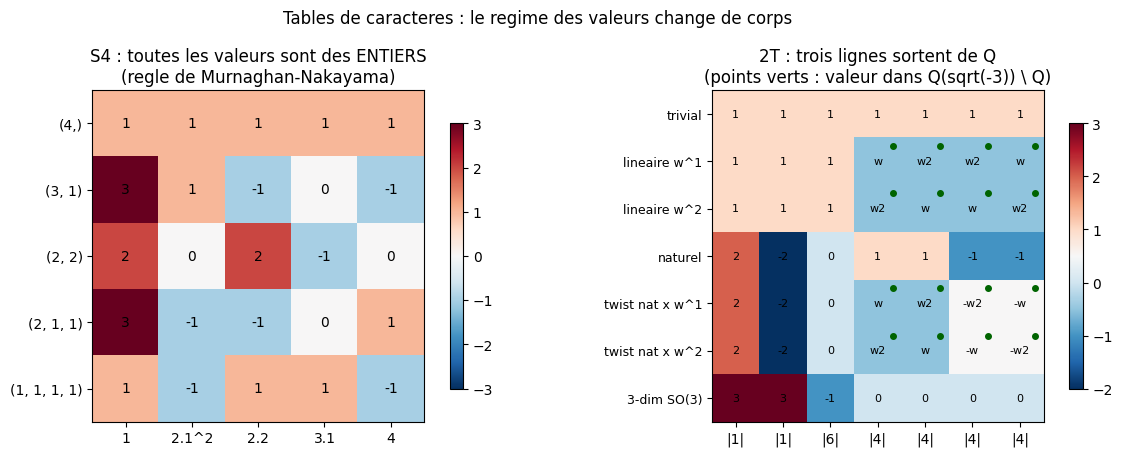

In [13]:
# ============================================================
# Figure : les deux regimes de valeurs -- S4 entier, 2T quadratique.
# Couleur = partie reelle a de a + b.sqrt(-3) ; les cases avec b != 0
# sont marquees d'un point : leur valeur est HORS de Q.
# ============================================================
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

# --- gauche : S4, valeurs entieres
import numpy as np
M4 = np.array([[t4[l][j] for j in range(5)] for l in t4], dtype=float)
im1 = ax1.imshow(M4, cmap="RdBu_r", vmin=-3, vmax=3)
ax1.set_xticks(range(5))
ax1.set_xticklabels(["1", "2.1^2", "2.2", "3.1", "4"])
ax1.set_yticks(range(5))
ax1.set_yticklabels([str(l) for l in t4])
for i in range(5):
    for j in range(5):
        ax1.text(j, i, str(t4[list(t4)[i]][j]), ha="center", va="center",
                 color="black", fontsize=10)
ax1.set_title("S4 : toutes les valeurs sont des ENTIERS\n(regle de Murnaghan-Nakayama)")
plt.colorbar(im1, ax=ax1, shrink=0.8)

# --- droite : 2T, partie reelle + marqueur b != 0
M2T = np.array([[float(v[0]) for v in ligne] for ligne in lignes_2t])
im2 = ax2.imshow(M2T, cmap="RdBu_r", vmin=-2, vmax=3)
ax2.set_xticks(range(7))
ax2.set_xticklabels([f"|{len(c)}|" for c in CL2T])
ax2.set_yticks(range(7))
ax2.set_yticklabels(noms, fontsize=9)
for i in range(7):
    for j in range(7):
        v = lignes_2t[i][j]
        ax2.text(j, i, w_str(v), ha="center", va="center", color="black", fontsize=8)
        if v[1] != 0:                      # partie quadratique non nulle
            ax2.plot(j + 0.32, i - 0.32, marker="o", color="darkgreen", markersize=4)
ax2.set_title("2T : trois lignes sortent de Q\n(points verts : valeur dans Q(sqrt(-3)) \\ Q)")
plt.colorbar(im2, ax=ax2, shrink=0.8)

fig.suptitle("Tables de caracteres : le regime des valeurs change de corps", fontsize=12)
fig.tight_layout()
plt.show()

### Lecture de la figure : deux régimes de valeurs

À gauche, la table de $S_4$ : aucune case marquée, toutes les valeurs sont entières —
positives sur la colonne identité (les degrés $1,1,2,3,3$), symétriques autour des zéros de
la colonne $3.1$. À droite, la table de $2T$ : les points verts signalent chaque valeur
hors de $\mathbb{Q}$, et ils dessinent **exactement** les deux lignes de twists non
triviaux — les cases $\omega, \omega^2, -\omega, -\omega^2$ — tandis que les lignes
triviale, naturelle et $3$-dim restent rationnelles. La structure est visible d'un coup
d'œil : le passage de $S_4$ à son revêtement double fait entrer le corps quadratique
imaginaire $\mathbb{Q}(\sqrt{-3})$ dans la table, et l'orthogonalité — vérifiée en exact
ci-dessus — n'est possible que parce que ces valeurs quadratiques y participent à part
entière.

## 5. Travaux pratiques

Trois exercices, du plus contraint au plus constructif. Les squelettes s'exécutent tels
quels (ils n'affirment rien tant qu'ils ne sont pas complétés) ; les `TODO` marquent le
travail, et chaque énoncé est auto-contenu. L'exercice 1 reconstruit les degrés de $A_5$
par la seule arithmétique de $\sum d^2 = |G|$, l'exercice 2 descend la table de $2T$ à
celle de $Q_8$, l'exercice 3 fait agir le twist par le signe sur la table de $S_4$ mesurée
en section 2.

In [14]:
# Exercice 1 : les degres de A5 sans calculer un seul caractere
# A5 (60 elements, simplicite) a 5 classes de conjugaison de tailles 1, 12, 12, 15, 20.
# Questions : (a) enumerer les 5-tuples de degres (d1=1) avec sum d^2 = 60 ;
# (b) restreindre par "d divise 60" et "5 lignes pour 5 classes" ;
# (c) conclure : quelle est la seule candidate, et que vaut la 4-dim sur les doubles
#     transpositions (15 elements) sachant que la 4-dim est la permutation de A5 sur
#     5 points moins la triviale ?
# TODO etudiant
print("Exercice 1 a completer : trouvez les degres de A5 (attendu : 1, 3, 3, 4, 5).")

def degres_A5():
    '''Renvoie le tuple croissant des 5 degres des irreps de A5.
    Indice : une boucle sur les tuples (d2..d5) avec d^2 sommant 59,
    puis filtrer par divisibilite (d | 60) et egalite du nombre de lignes.'''
    pass  # TODO etudiant
    return None  # TODO etudiant

# Piste (a decommenter) :
# from itertools import product
# cands = [ (1,) + t for t in product(range(1, 11), repeat=4)
#           if 1 + sum(d*d for d in t) == 60 ]
# print(len(cands), "candidates avant divisibilite ;", len([c for c in cands
#           if all(60 % d == 0 for d in c)]), "apres d | 60")

Exercice 1 a completer : trouvez les degres de A5 (attendu : 1, 3, 3, 4, 5).


In [15]:
# Exercice 2 : descendre la table -- restriction du caractere naturel a Q8
# Q8 = {+-1, +-i, +-j, +-k} est un sous-groupe de 2T. Questions :
# (a) restreindre chi_nat a Q8 et verifier les valeurs par ordre {1: 2, 2: -2, 4: 0} ;
# (b) montrer que Q8/[Q8,Q8] = Q8/{+-1} = C2 x C2 (abelianisation), donc 4 lineaires ;
# (c) ecrire la table 4 + 1 de Q8 et verifier sum d^2 = 8.
# TODO etudiant
print("Exercice 2 a completer : construisez la table de caracteres de Q8 (4 x 1 et une 2-dim).")

def table_Q8():
    '''Renvoie la table de Q8 : liste de lignes [chi par classe], classes (1), (-1), (+-i/j/k).
    Indice : les 4 lineaires factorisent par Q8/{+-1} ; la 2-dim est chi_nat|Q8.'''
    pass  # TODO etudiant
    return None  # TODO etudiant

# Piste (a decommenter) :
# cl_q8 = [[UN], [Q8[1]], sorted(Q8[2:], key=str)]
# for c in cl_q8:
#     print("ordre", ordre(c[0]), "-> chi_nat =", caractere_naturel(c[0]))
# Somme attendue en (c) : 1 + 1 + 1 + 1 + 4 = 8 = |Q8|

Exercice 2 a completer : construisez la table de caracteres de Q8 (4 x 1 et une 2-dim).


In [16]:
# Exercice 3 : le twist par le signe echange deux lignes de S4
# Dans S_n, tordre une representation par le caractere signe eps donne une nouvelle
# irrep de meme degre. Questions :
# (a) extraire la ligne (3,1) (standard) et la ligne signe de t4, construire leur
#     produit terme a terme, et comparer a la ligne (2,1,1) ;
# (b) meme verification par MN : montrer que mn_char((2,1,1), mu) se deduit de
#     mn_char((3,1), mu) et du signe de mu SANS re-enumerer les equerres ;
# (c) que se passe-t-il pour les lignes (4) et (2,2) ?
# TODO etudiant
print("Exercice 3 a completer : verifiez std x signe = ligne (2,1,1) de S4.")

def twist_signe(ligne, signes):
    '''Produit terme a terme de deux caracteres (listes d'entiers).'''
    pass  # TODO etudiant
    return None  # TODO etudiant

# Piste (a decommenter) :
# signes = [(-1) ** (4 - len(mu)) for mu in S4_CLASSES]
# prod = [a * b for a, b in zip(t4[(3, 1)], signes)]
# print("std x signe :", prod)
# print("ligne (2,1,1):", t4[(2, 1, 1)], "-> egalite :", prod == t4[(2, 1, 1)])

Exercice 3 a completer : verifiez std x signe = ligne (2,1,1) de S4.


## 6. Conclusion et limites honnêtes

**Ce que cette exécution a mesuré** (toutes les identités en `Fraction` exactes — le
seul flottant du notebook est l'échelle de couleur de la figure) :

| # | Fait | Statut |
|---|---|---|
| 1 | Murnaghan–Nakayama reproduit les tables de $S_3$ et $S_4$ ; standard $=$ points fixes $- 1$, signe $= (-1)^{n-\#\text{cyc}}$ | mesuré + temoins indépendants |
| 2 | Orthogonalité des lignes (28+21 paires) et colonnes (25 paires) de $S_4$ ; $\sum d^2 = 24$ ; $\#\text{irr} = \#\text{classes}$ | mesuré, Fractions exactes |
| 3 | $2T$ : 24 quaternions fermés, 7 classes de tailles $1,1,6,4,4,4,4$, centre $\{\pm 1\}$, $-1$ seul élément d'ordre 2 | mesuré (conjugaison brute) |
| 4 | $\chi_{\text{nat}}$ $=$ trace $2a$ de la représentation $2\times 2$ sur $\mathbb{Q}(i)$ ; valeurs $2, -2, 0, \pm 1, \pm 1, \mp 1, \mp 1$ | mesuré, exact |
| 5 | $2T/Q_8 \cong C_3$ (morphisme $\phi$ vérifié $24 \times 24$) $\Rightarrow$ $1+1+1+2^2+2^2+2^2+3^2 = 24$ : la forme de la table était contrainte | mesuré + arithmétique |
| 6 | Table $7 \times 7$ sur $\mathbb{Q}(\sqrt{-3})$, twists inclus ; orthogonalité des 49 paires avec conjugaison $(a, -b)$ | mesuré, paires exactes |
| 7 | La 3-dim $4a^2 - 1$ : valeurs $3, 3, -1, 0, 0, 0, 0$ ($-1$ est le noyau de $2T \to \mathrm{SO}(3)$) | mesuré |

**Limites.** L'énumération des équerres est exponentielle : la machine convient jusqu'à
$S_6$–$S_7$ et pas au-delà (les tables de grands groupes symétriques demandent l'algorithme
de boilers ou les polynômes de Frobenius, hors scope). La construction de la table de $2T$
**suppose** la classification des irréductibles (3 linéaires + twists + 3-dim) déduite de
l'abélianisation et de $\sum d^2 = 24$ : l'irréductibilité des twists est vérifiée par leur
norme (24), pas par une décomposition explicite de représentations. Enfin, l'exercice 1
reconstruit des **degrés**, pas des caractères : la table complète de $A_5$ exigerait les
valeurs colonne par colonne, qui suivent des arguments géométriques (le cube et
l'icosaèdre) non exécutés ici.